# Extension Study

This notebook extends the core `highway-v0` benchmark with one integrated custom-DQN study.

We answer three questions:

1. Does the observation representation matter?
2. Do Double DQN and Prioritized Experience Replay improve the kinematics baseline?
3. Can reward shaping and training on more diverse traffic settings produce a safer and more robust policy?

All experiments use the same `rl/` module and the same evaluation metrics:
- mean return
- return standard deviation
- mean episode length
- crash rate
- mean speed
- actual lane-change rate


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from rl.train import train
from rl.evaluate import (
    evaluate_custom_agent_suite,
    record_custom_rollout,
    find_custom_failure_case,
)
from rl.visualize import (
    plot_training_curve,
    plot_extension_metric,
    plot_generalization_gap,
    make_extension_summary_table,
    plot_pilot_safe_results,
    show_side_by_side_gifs,
    print_rollout_summary,
    print_failure_case,
)
from rl.extension_configs import (
    SAFE_PILOT_EVAL_ENVS,
    build_eval_config,
    build_eval_config_suite,
    make_observation_variants,
    make_algorithm_variants,
    make_pilot_variants,
    make_safety_variants,
    make_training_kwargs,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

ARTIFACTS = Path("artifacts/final_extension")
ARTIFACTS.mkdir(parents=True, exist_ok=True)

OBS_TRAIN_SEEDS = [0, 1]
OBS_EVAL_SEEDS = list(range(1000, 1020))
OBS_TOTAL_STEPS = 10_000
OBS_EVAL_ENVS = ["shared"]

ALGO_TRAIN_SEEDS = [0, 1, 2]
ALGO_EVAL_SEEDS = list(range(1000, 1030))
ALGO_TOTAL_STEPS = 12_000
ALGO_EVAL_ENVS = ["shared"]

PILOT_TRAIN_SEEDS = [0]
PILOT_EVAL_SEEDS = list(range(1000, 1010))
PILOT_TOTAL_STEPS = 8_000

SAFETY_TRAIN_SEEDS = [0, 1, 2]
SAFETY_EVAL_SEEDS = list(range(1000, 1030))
SAFETY_TOTAL_STEPS = 12_000
SAFETY_EVAL_ENVS = ["shared", "dense", "sparse", "narrow", "wide", "stress"]


def run_training_study(study_name, variants, train_seeds, total_steps):
    agents_by_run = {}
    metrics_by_run = {}

    for variant_name in variants:
        for seed in train_seeds:
            agent, metrics = train(
                seed=seed,
                run_dir=ARTIFACTS / study_name / variant_name / f"seed_{seed}",
                total_steps=total_steps,
                verbose=False,
                **make_training_kwargs(variant_name, variants),
            )
            agents_by_run[(variant_name, seed)] = agent
            metrics_by_run[(variant_name, seed)] = metrics

    return agents_by_run, metrics_by_run


def run_evaluation_study(study_name, variants, agents_by_run, eval_seeds, eval_env_names):
    rows = []

    for (variant_name, train_seed), agent in agents_by_run.items():
        eval_configs = build_eval_config_suite(
            eval_env_names,
            observation_mode=variants[variant_name]["observation_mode"],
        )
        rows.extend(
            evaluate_custom_agent_suite(
                agent,
                seeds=eval_seeds,
                eval_configs=eval_configs,
                variant_name=variant_name,
                train_seed=train_seed,
            )
        )

    results_df = pd.DataFrame(rows)
    results_df.to_csv(ARTIFACTS / study_name / "results.csv", index=False)
    return results_df


def show_training_curves(metrics_by_run, variants, train_seeds):
    for variant_name in variants:
        for seed in train_seeds:
            plot_training_curve(
                metrics_by_run[(variant_name, seed)],
                label=f"{variant_name} seed {seed}",
            )


def rank_variants(results_df):
    return (
        results_df.groupby("variant")[["crash_rate", "mean_return", "mean_length"]]
        .mean()
        .sort_values(
            ["crash_rate", "mean_return", "mean_length"],
            ascending=[True, False, False],
        )
    )


/Users/tomas/Documents/Cours 2025-2026/Current/RL/Projet/.venv/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Study A — Observation Representation

We first isolate the effect of the observation type.

This section compares:
- `Kinematics` with an MLP
- `OccupancyGrid` with a CNN

No algorithmic extras are enabled here:
- no Double DQN
- no PER
- no reward shaping
- no mixed-traffic training

The goal is descriptive: we want to see whether the richer spatial representation helps enough to justify its extra complexity.


In [2]:
observation_variants = make_observation_variants()
observation_variants


{'kinematics_baseline': {'safe_preset': None,
  'traffic_names': ['shared'],
  'observation_mode': 'kinematics',
  'double_dqn': False,
  'prioritized_replay': False},
 'occupancy_grid_baseline': {'safe_preset': None,
  'traffic_names': ['shared'],
  'observation_mode': 'occupancy_grid',
  'double_dqn': False,
  'prioritized_replay': False}}

In [3]:
obs_agents, obs_metrics = run_training_study(
    study_name="observation_study",
    variants=observation_variants,
    train_seeds=OBS_TRAIN_SEEDS,
    total_steps=OBS_TOTAL_STEPS,
)


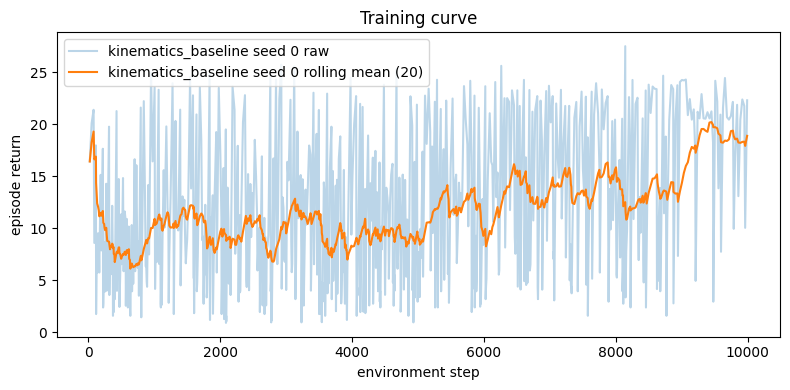

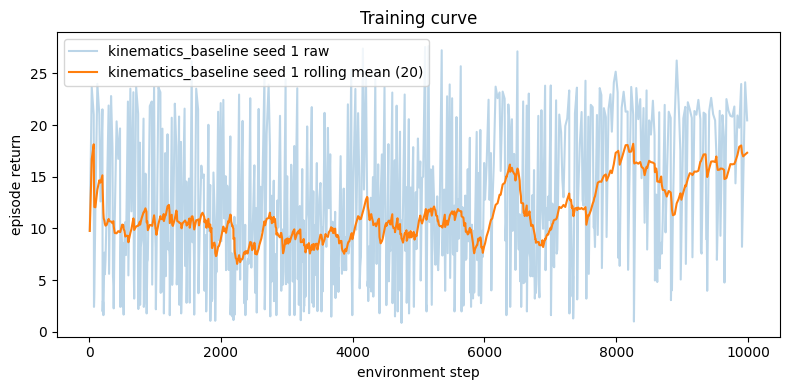

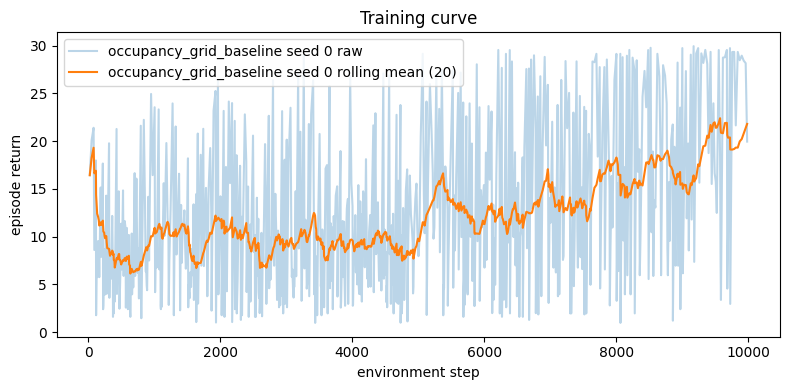

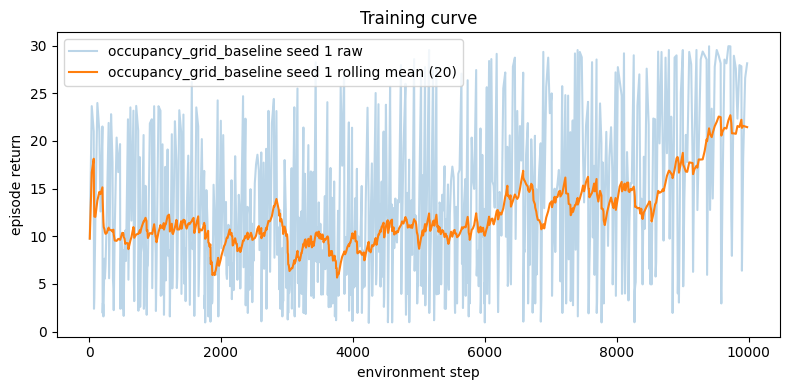

In [4]:
show_training_curves(obs_metrics, observation_variants, OBS_TRAIN_SEEDS)


,variant,train_seed,eval_env,mean_return,std_return,mean_length,crash_rate,mean_speed,actual_lane_change_rate
0,kinematics_baseline,0,shared,21.076,3.286,28.15,0.15,22.743,0.232
1,kinematics_baseline,1,shared,19.545,4.333,27.55,0.15,21.423,0.075
2,occupancy_grid_baseline,0,shared,23.735,9.481,25.25,0.20,28.344,0.371
3,occupancy_grid_baseline,1,shared,24.194,8.186,25.40,0.30,28.934,0.306


mean_return        std_return        mean_length        crash_rate        mean_speed        actual_lane_change_rate       
                                        mean    std       mean    std        mean    std       mean    std       mean    std                    mean    std
variant                 eval_env                                                                                                                           
kinematics_baseline     shared        20.311  1.082      3.810  0.740      27.850  0.424       0.15  0.000     22.083  0.933                   0.154  0.111
occupancy_grid_baseline shared        23.964  0.324      8.833  0.916      25.325  0.106       0.25  0.071     28.639  0.417                   0.339  0.046

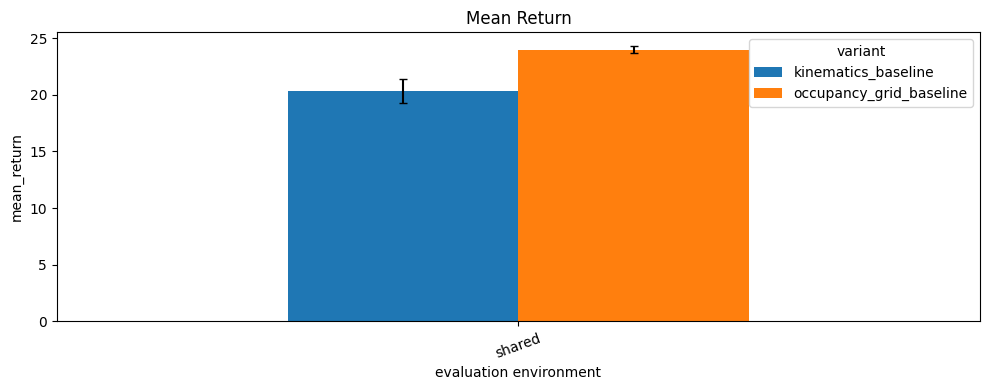

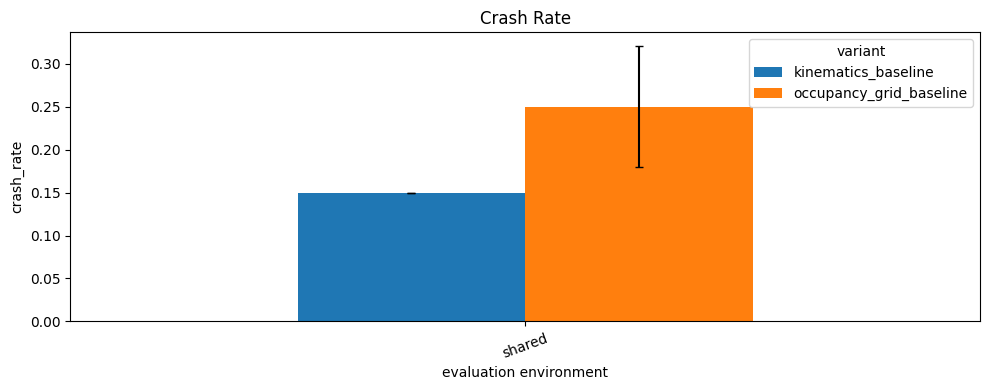

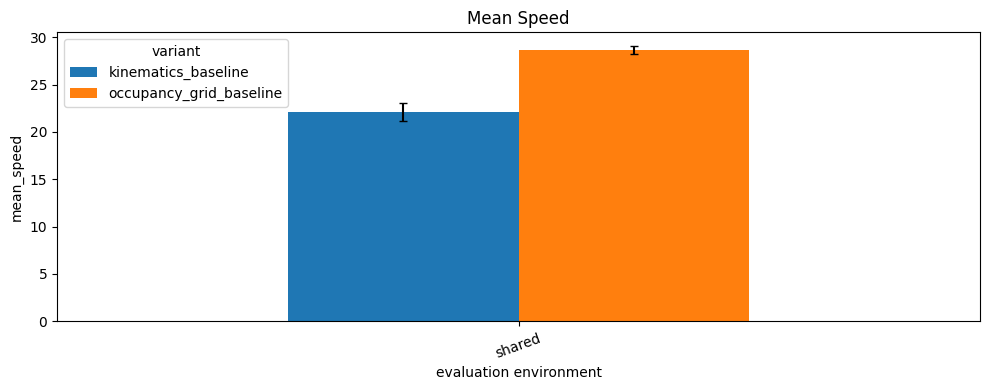

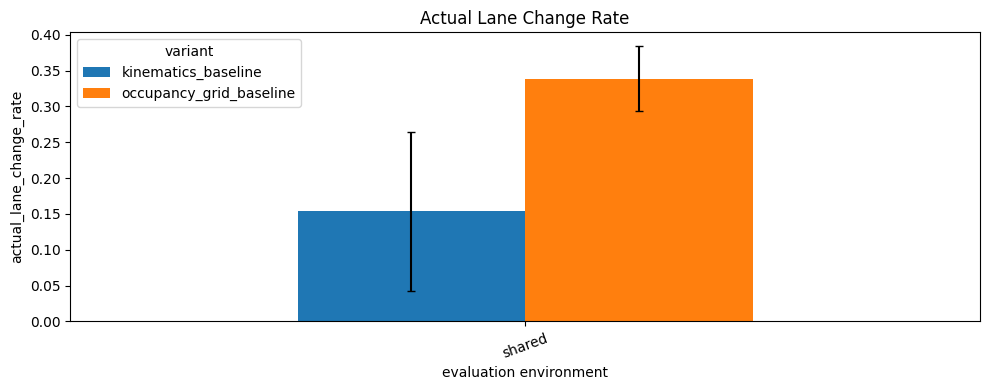

In [5]:
obs_results_df = run_evaluation_study(
    study_name="observation_study",
    variants=observation_variants,
    agents_by_run=obs_agents,
    eval_seeds=OBS_EVAL_SEEDS,
    eval_env_names=OBS_EVAL_ENVS,
)

display(obs_results_df.round(3))
display(make_extension_summary_table(obs_results_df))

plot_extension_metric(obs_results_df, "mean_return")
plot_extension_metric(obs_results_df, "crash_rate")
plot_extension_metric(obs_results_df, "mean_speed")
plot_extension_metric(obs_results_df, "actual_lane_change_rate")


In [6]:
observation_ranking = rank_variants(obs_results_df)
display(observation_ranking.round(3))

OBSERVATION_BACKBONE = "kinematics"
print("We keep kinematics for the rest of the notebook to stay aligned with the shared core setup.")


,crash_rate,mean_return,mean_length
variant,,,
kinematics_baseline,0.15,20.311,27.850
occupancy_grid_baseline,0.25,23.964,25.325


We keep kinematics for the rest of the notebook to stay aligned with the shared core setup.


## Study B — Algorithmic Improvements on the Kinematics Baseline

We now keep the `Kinematics` observation fixed and compare four variants:

- baseline DQN
- Double DQN
- DQN with PER
- DQN with both PER and Double DQN

This tells us whether the main algorithmic improvements are actually useful in this benchmark before we move to safety-oriented training.


In [7]:
algorithm_variants = make_algorithm_variants(observation_mode=OBSERVATION_BACKBONE)
algorithm_variants


{'kinematics_baseline': {'safe_preset': None,
  'traffic_names': ['shared'],
  'observation_mode': 'kinematics',
  'double_dqn': False,
  'prioritized_replay': False},
 'kinematics_double': {'safe_preset': None,
  'traffic_names': ['shared'],
  'observation_mode': 'kinematics',
  'double_dqn': True,
  'prioritized_replay': False},
 'kinematics_per': {'safe_preset': None,
  'traffic_names': ['shared'],
  'observation_mode': 'kinematics',
  'double_dqn': False,
  'prioritized_replay': True},
 'kinematics_per_double': {'safe_preset': None,
  'traffic_names': ['shared'],
  'observation_mode': 'kinematics',
  'double_dqn': True,
  'prioritized_replay': True}}

In [8]:
algo_agents, algo_metrics = run_training_study(
    study_name="algorithm_study",
    variants=algorithm_variants,
    train_seeds=ALGO_TRAIN_SEEDS,
    total_steps=ALGO_TOTAL_STEPS,
)


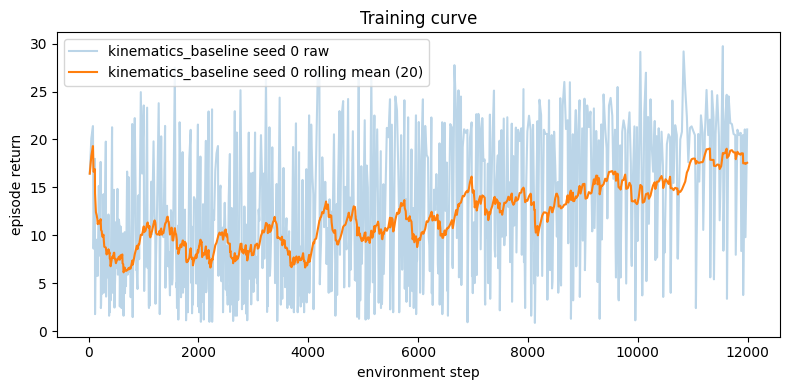

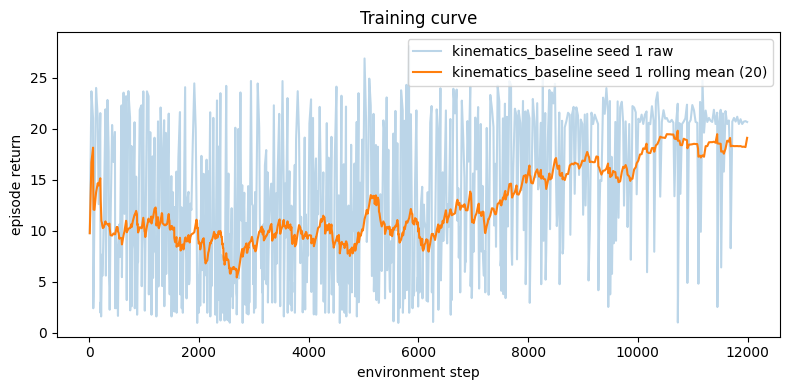

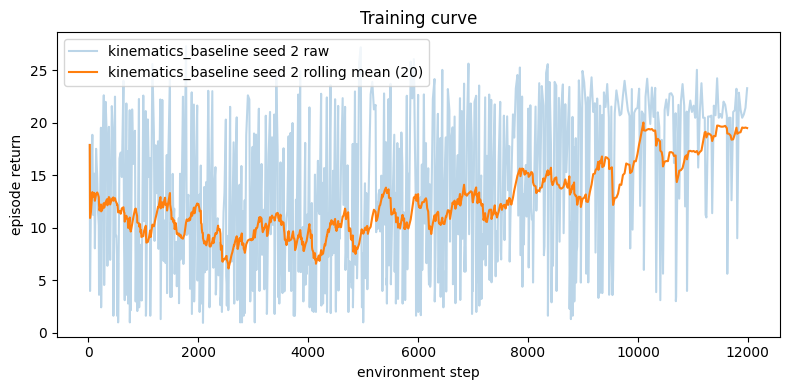

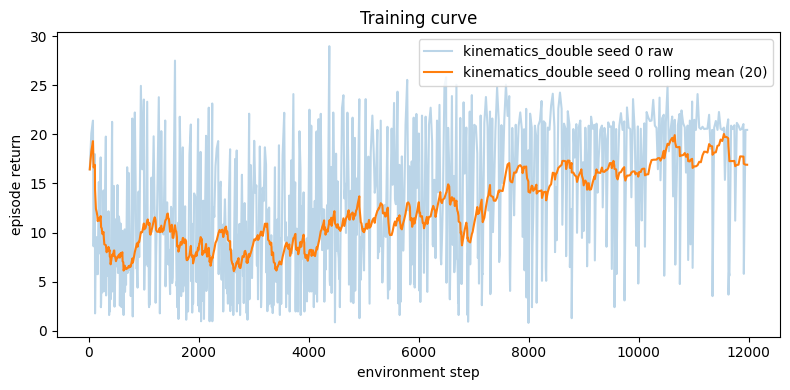

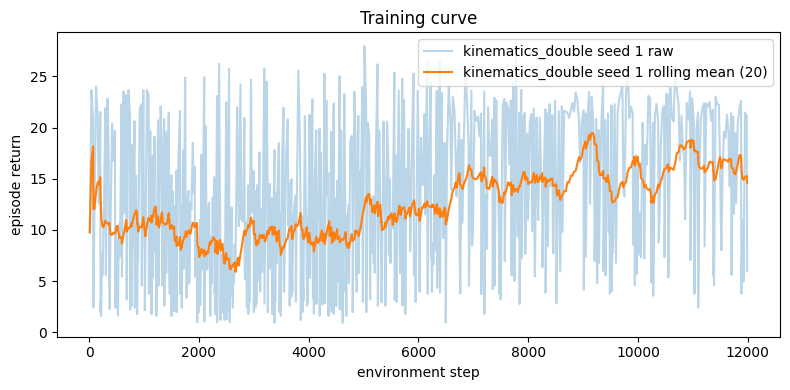

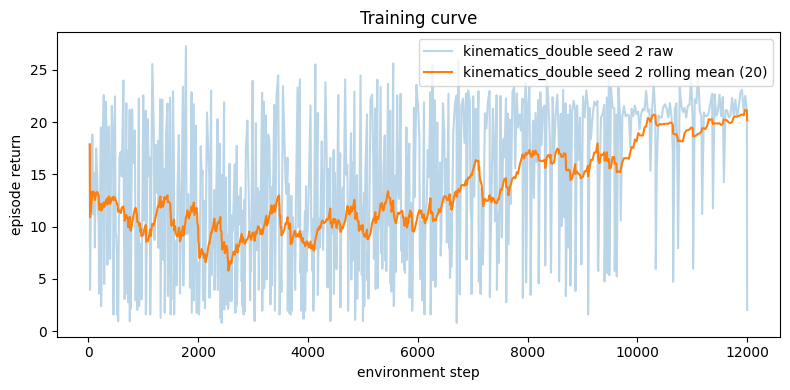

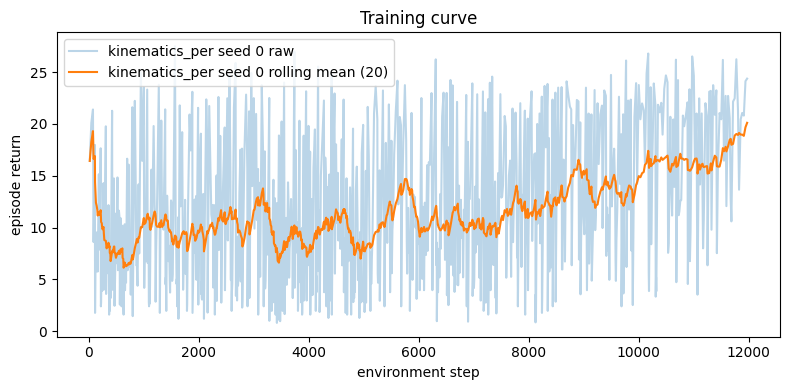

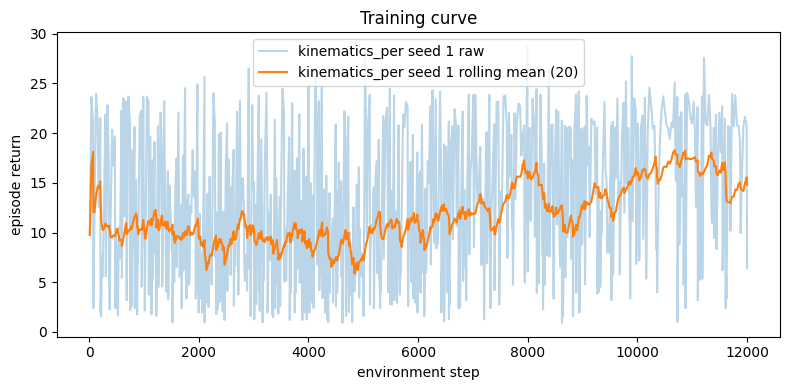

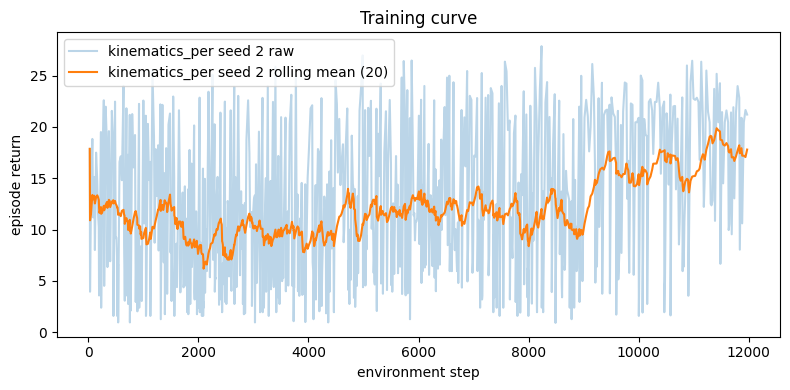

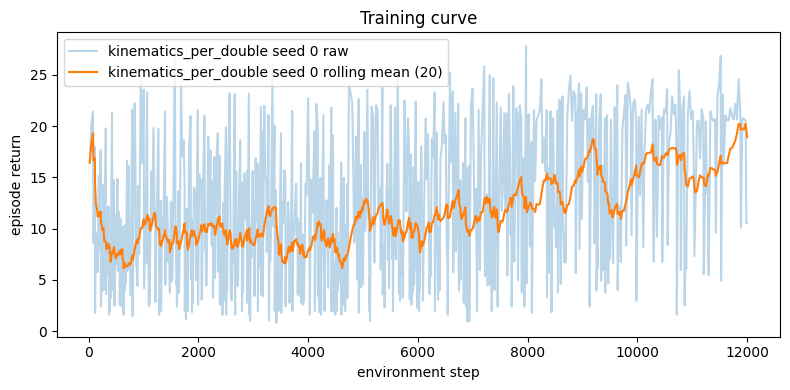

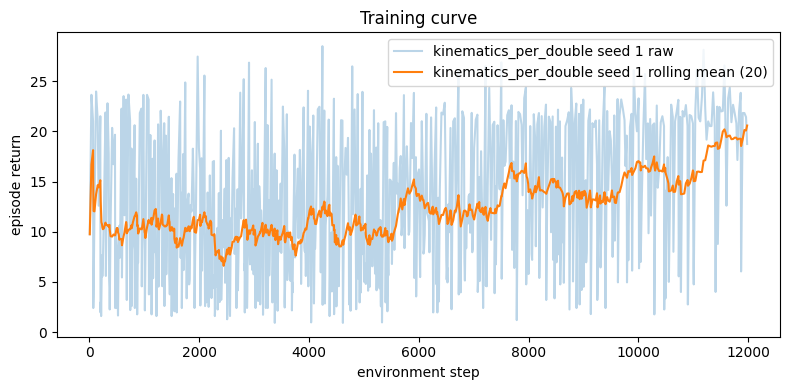

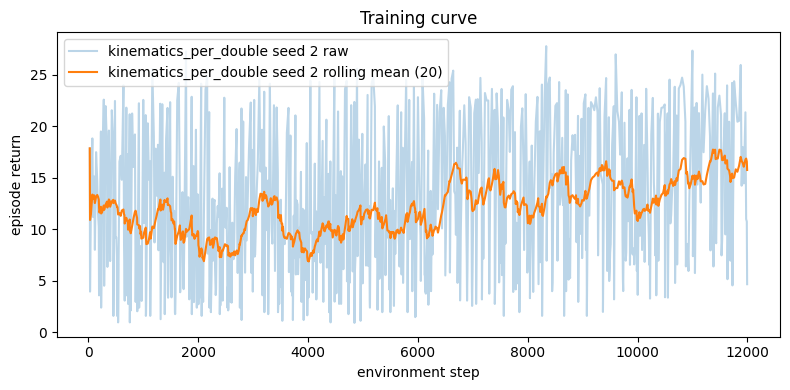

In [9]:
show_training_curves(algo_metrics, algorithm_variants, ALGO_TRAIN_SEEDS)


,variant,train_seed,eval_env,mean_return,std_return,mean_length,crash_rate,mean_speed,actual_lane_change_rate
0,kinematics_baseline,0,shared,16.321,6.360,21.833,0.567,23.668,0.164
1,kinematics_baseline,1,shared,18.842,5.057,26.767,0.200,21.329,0.331
2,kinematics_baseline,2,shared,20.010,3.063,28.833,0.067,20.704,0.537
3,kinematics_double,0,shared,19.363,4.516,27.267,0.167,21.466,0.150
4,kinematics_double,1,shared,19.399,4.717,26.533,0.267,22.438,0.237
5,kinematics_double,2,shared,20.184,1.858,29.433,0.033,20.298,0.155
6,kinematics_per,0,shared,18.352,5.613,24.600,0.367,23.225,0.118
7,kinematics_per,1,shared,11.500,6.502,14.633,0.867,25.724,0.272
8,kinematics_per,2,shared,19.534,5.258,25.867,0.300,23.308,0.165
9,kinematics_per_double,0,shared,11.790,5.966,14.900,0.833,25.958,0.168


mean_return        std_return        mean_length        crash_rate        mean_speed        actual_lane_change_rate       
                                      mean    std       mean    std        mean    std       mean    std       mean    std                    mean    std
variant               eval_env                                                                                                                           
kinematics_baseline   shared        18.391  1.885      4.827  1.661      25.811  3.597      0.278  0.259     21.900  1.563                   0.344  0.187
kinematics_double     shared        19.649  0.464      3.697  1.596      27.744  1.508      0.156  0.117     21.400  1.071                   0.181  0.049
kinematics_per        shared        16.462  4.338      5.791  0.641      21.700  6.153      0.511  0.310     24.085  1.420                   0.185  0.079
kinematics_per_double shared        15.093  3.323      5.893  0.213      19.767  5.212      0.589  0.291     24.638  1.686                   0.159  0.008

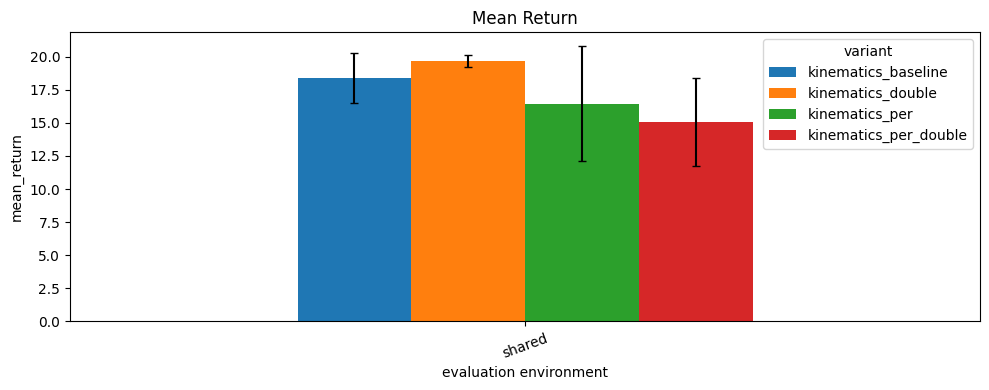

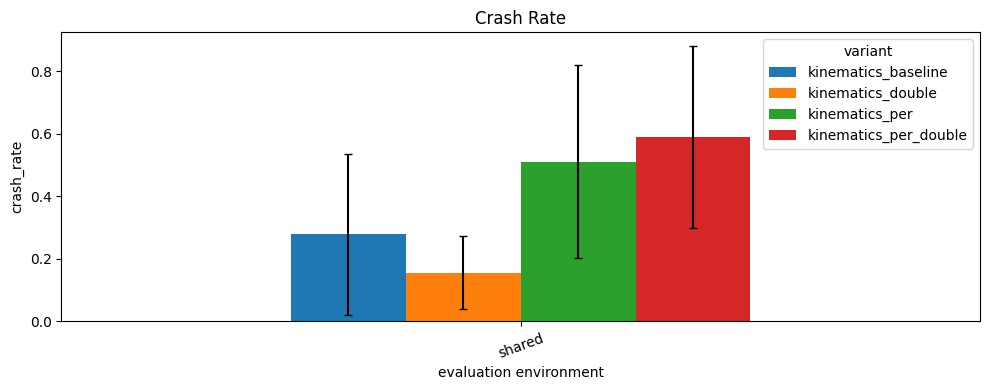

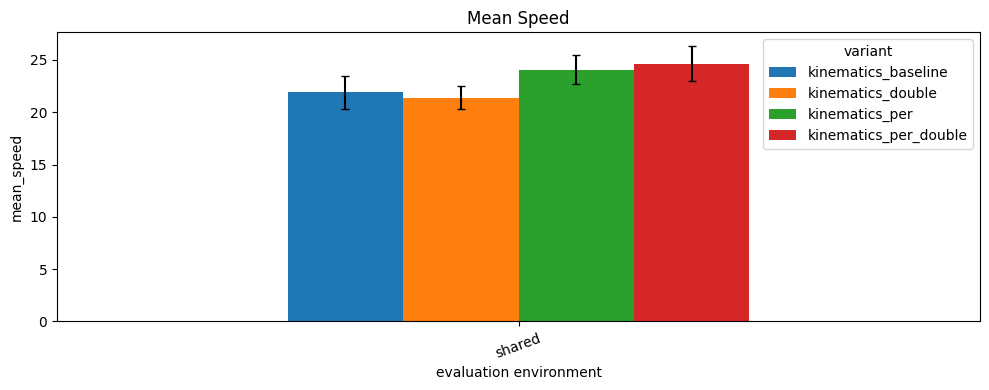

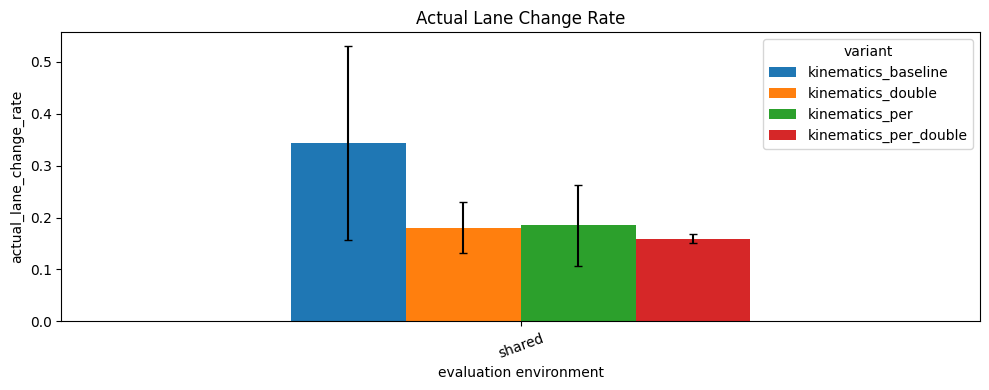

In [10]:
algo_results_df = run_evaluation_study(
    study_name="algorithm_study",
    variants=algorithm_variants,
    agents_by_run=algo_agents,
    eval_seeds=ALGO_EVAL_SEEDS,
    eval_env_names=ALGO_EVAL_ENVS,
)

display(algo_results_df.round(3))
display(make_extension_summary_table(algo_results_df))

plot_extension_metric(algo_results_df, "mean_return")
plot_extension_metric(algo_results_df, "crash_rate")
plot_extension_metric(algo_results_df, "mean_speed")
plot_extension_metric(algo_results_df, "actual_lane_change_rate")


In [11]:
algorithm_ranking = rank_variants(algo_results_df)
display(algorithm_ranking.round(3))

BEST_BACKBONE_NAME = algorithm_ranking.index[0]
BEST_BACKBONE_VARIANT = algorithm_variants[BEST_BACKBONE_NAME]

print("Selected algorithmic backbone:", BEST_BACKBONE_NAME)
print(BEST_BACKBONE_VARIANT)


,crash_rate,mean_return,mean_length
variant,,,
kinematics_double,0.156,19.649,27.744
kinematics_baseline,0.278,18.391,25.811
kinematics_per,0.511,16.462,21.700
kinematics_per_double,0.589,15.093,19.767


Selected algorithmic backbone: kinematics_double
{'safe_preset': None, 'traffic_names': ['shared'], 'observation_mode': 'kinematics', 'double_dqn': True, 'prioritized_replay': False}


## Study C — Safe Reward Preset Pilot

Before launching the final safety study, we first search over a small family of explicit safe-reward presets.

Selection rule:
1. minimize average crash rate on `dense` and `stress`
2. reject any preset whose shared-config return is below 90% of the baseline
3. among remaining presets, keep the one with the highest shared-config return

This keeps the safe reward honest: it should improve safety without collapsing the task.


In [12]:
pilot_variants = make_pilot_variants(observation_mode=OBSERVATION_BACKBONE)
pilot_variants


{'baseline_shared': {'safe_preset': None,
  'traffic_names': ['shared'],
  'observation_mode': 'kinematics',
  'double_dqn': False,
  'prioritized_replay': False},
 'safe_v1_mild': {'safe_preset': 'safe_v1_mild',
  'traffic_names': ['shared'],
  'observation_mode': 'kinematics',
  'double_dqn': False,
  'prioritized_replay': False},
 'safe_v2_balanced': {'safe_preset': 'safe_v2_balanced',
  'traffic_names': ['shared'],
  'observation_mode': 'kinematics',
  'double_dqn': False,
  'prioritized_replay': False},
 'safe_v3_strong': {'safe_preset': 'safe_v3_strong',
  'traffic_names': ['shared'],
  'observation_mode': 'kinematics',
  'double_dqn': False,
  'prioritized_replay': False},
 'safe_v4_crash_only': {'safe_preset': 'safe_v4_crash_only',
  'traffic_names': ['shared'],
  'observation_mode': 'kinematics',
  'double_dqn': False,
  'prioritized_replay': False}}

In [13]:
pilot_agents, pilot_metrics = run_training_study(
    study_name="safe_preset_pilot",
    variants=pilot_variants,
    train_seeds=PILOT_TRAIN_SEEDS,
    total_steps=PILOT_TOTAL_STEPS,
)


,variant,train_seed,eval_env,mean_return,std_return,mean_length,crash_rate,mean_speed,actual_lane_change_rate
0,baseline_shared,0,shared,16.538,6.788,20.6,0.7,25.438,0.192
1,baseline_shared,0,dense,11.876,7.309,16.5,0.7,22.854,0.261
2,baseline_shared,0,stress,9.041,5.893,12.0,0.9,25.283,0.186
3,safe_v1_mild,0,shared,18.931,4.086,26.5,0.2,22.151,0.256
4,safe_v1_mild,0,dense,13.235,6.961,19.4,0.7,21.002,0.263
5,safe_v1_mild,0,stress,13.215,5.775,19.2,0.9,21.805,0.202
6,safe_v2_balanced,0,shared,18.869,4.983,26.3,0.3,21.887,0.169
7,safe_v2_balanced,0,dense,13.137,6.940,18.3,0.7,22.501,0.209
8,safe_v2_balanced,0,stress,9.560,6.579,13.7,0.8,22.192,0.280
9,safe_v3_strong,0,shared,19.582,2.893,28.7,0.1,20.095,0.255


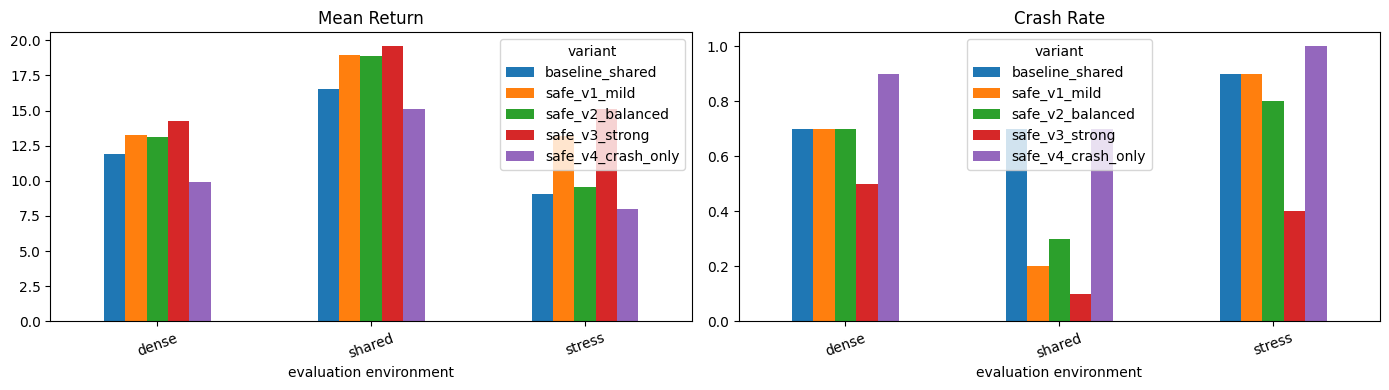

In [14]:
pilot_df = run_evaluation_study(
    study_name="safe_preset_pilot",
    variants=pilot_variants,
    agents_by_run=pilot_agents,
    eval_seeds=PILOT_EVAL_SEEDS,
    eval_env_names=SAFE_PILOT_EVAL_ENVS,
)

display(pilot_df.round(3))
plot_pilot_safe_results(pilot_df)


In [15]:
pilot_summary = (
    pilot_df.groupby(["variant", "eval_env"])[
        ["mean_return", "crash_rate", "mean_speed", "actual_lane_change_rate"]
    ]
    .mean()
    .reset_index()
)

baseline_shared_return = pilot_summary[
    (pilot_summary["variant"] == "baseline_shared")
    & (pilot_summary["eval_env"] == "shared")
]["mean_return"].iloc[0]

selection_rows = []
for variant_name in pilot_variants:
    if variant_name == "baseline_shared":
        continue

    shared_return = pilot_summary[
        (pilot_summary["variant"] == variant_name)
        & (pilot_summary["eval_env"] == "shared")
    ]["mean_return"].iloc[0]

    dense_crash = pilot_summary[
        (pilot_summary["variant"] == variant_name)
        & (pilot_summary["eval_env"] == "dense")
    ]["crash_rate"].iloc[0]

    stress_crash = pilot_summary[
        (pilot_summary["variant"] == variant_name)
        & (pilot_summary["eval_env"] == "stress")
    ]["crash_rate"].iloc[0]

    selection_rows.append(
        {
            "variant": variant_name,
            "shared_return": shared_return,
            "shared_return_ratio": shared_return / baseline_shared_return,
            "avg_shifted_crash": np.mean([dense_crash, stress_crash]),
            "dense_crash": dense_crash,
            "stress_crash": stress_crash,
        }
    )

selection_df = pd.DataFrame(selection_rows).sort_values(
    ["avg_shifted_crash", "shared_return"],
    ascending=[True, False],
)

eligible_df = selection_df[selection_df["shared_return_ratio"] >= 0.9].sort_values(
    ["avg_shifted_crash", "shared_return"],
    ascending=[True, False],
)

SELECTED_SAFE_PRESET = (
    eligible_df.iloc[0]["variant"]
    if len(eligible_df) > 0
    else selection_df.iloc[0]["variant"]
)

display(selection_df.round(3))
print("Selected safe preset:", SELECTED_SAFE_PRESET)


,variant,shared_return,shared_return_ratio,avg_shifted_crash,dense_crash,stress_crash
2,safe_v3_strong,19.582,1.184,0.45,0.5,0.4
1,safe_v2_balanced,18.869,1.141,0.75,0.7,0.8
0,safe_v1_mild,18.931,1.145,0.80,0.7,0.9
3,safe_v4_crash_only,15.102,0.913,0.95,0.9,1.0


Selected safe preset: safe_v3_strong


## Study D — Safety and Generalization With the Best Backbone

We now keep the best algorithmic backbone fixed and ask the main extension question:

Can explicit reward shaping and training on more diverse traffic conditions produce a safer and more robust policy?

We compare:
- best backbone with the baseline reward on shared traffic
- best backbone with the safe reward on shared traffic
- best backbone with the safe reward and mixed-traffic training


In [16]:
safety_variants = make_safety_variants(
    best_backbone_name=BEST_BACKBONE_NAME,
    best_backbone_variant=BEST_BACKBONE_VARIANT,
    selected_safe_preset=SELECTED_SAFE_PRESET,
)
safety_variants


{'bestalgo_shared_baseline_reward': {'observation_mode': 'kinematics',
  'double_dqn': True,
  'prioritized_replay': False,
  'source_backbone': 'kinematics_double',
  'safe_preset': None,
  'traffic_names': ['shared']},
 'bestalgo_shared_safe_reward': {'observation_mode': 'kinematics',
  'double_dqn': True,
  'prioritized_replay': False,
  'source_backbone': 'kinematics_double',
  'safe_preset': 'safe_v3_strong',
  'traffic_names': ['shared']},
 'bestalgo_mixed_safe_reward': {'observation_mode': 'kinematics',
  'double_dqn': True,
  'prioritized_replay': False,
  'source_backbone': 'kinematics_double',
  'safe_preset': 'safe_v3_strong',
  'traffic_names': ['shared', 'dense', 'sparse', 'narrow', 'wide']}}

In [17]:
safety_agents, safety_metrics = run_training_study(
    study_name="safety_study",
    variants=safety_variants,
    train_seeds=SAFETY_TRAIN_SEEDS,
    total_steps=SAFETY_TOTAL_STEPS,
)


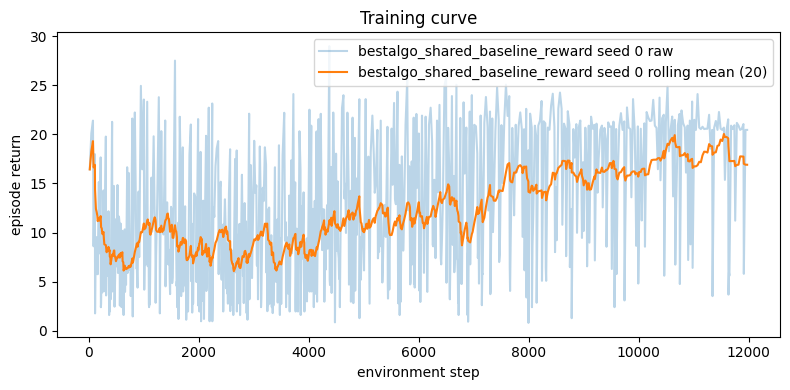

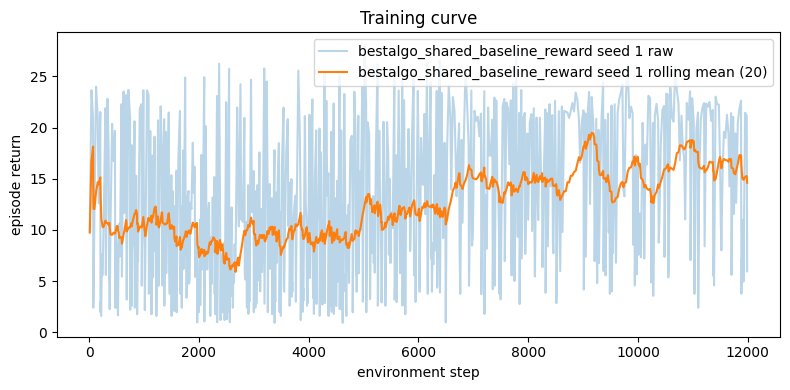

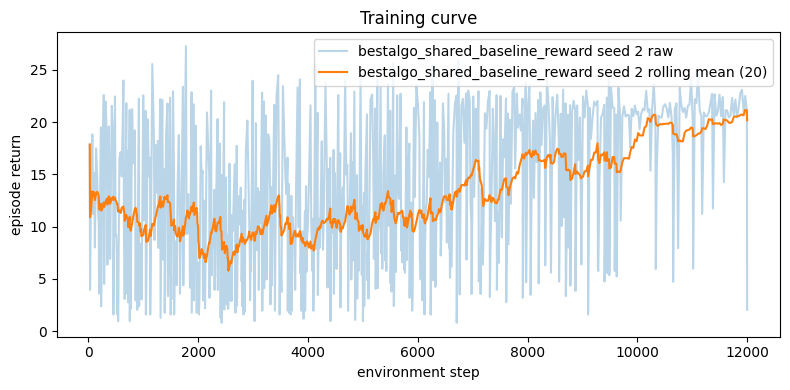

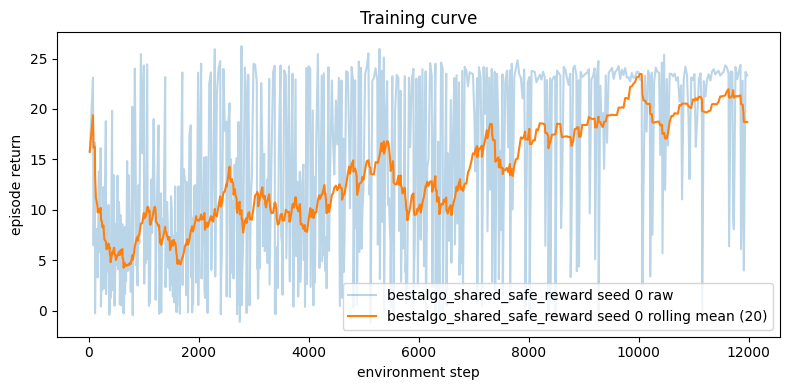

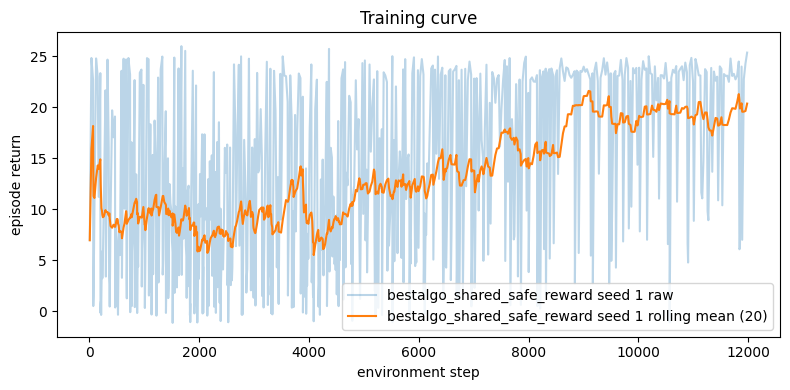

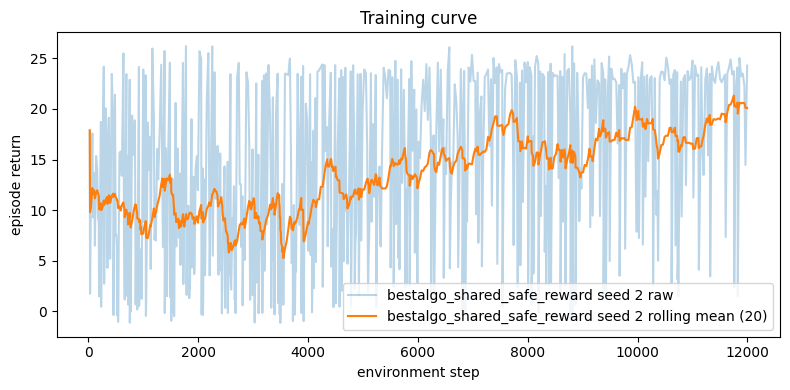

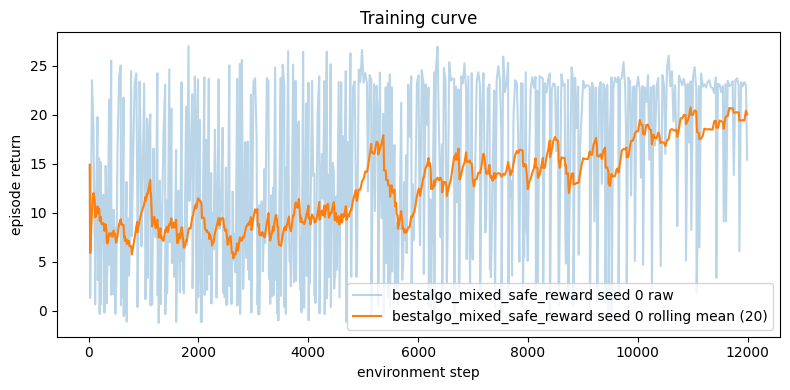

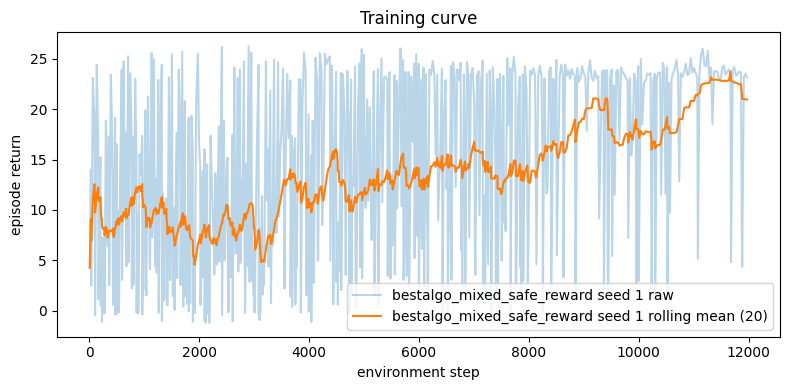

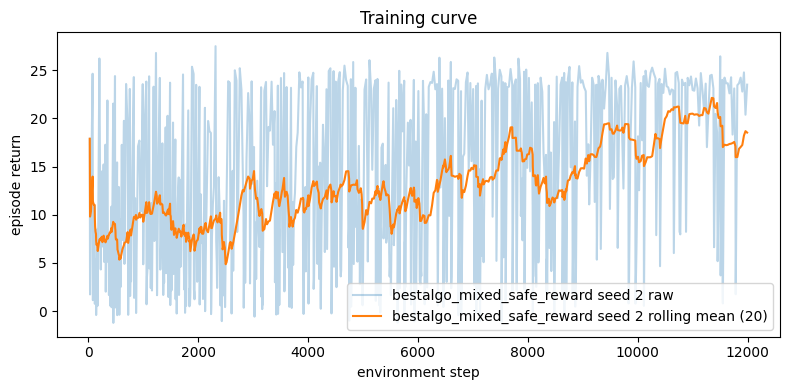

In [18]:
show_training_curves(safety_metrics, safety_variants, SAFETY_TRAIN_SEEDS)


,variant,train_seed,eval_env,mean_return,std_return,mean_length,crash_rate,mean_speed,actual_lane_change_rate
0,bestalgo_shared_baseline_reward,0,shared,19.363,4.516,27.267,0.167,21.466,0.150
1,bestalgo_shared_baseline_reward,0,dense,15.482,6.724,22.133,0.533,21.813,0.219
2,bestalgo_shared_baseline_reward,0,sparse,20.651,1.990,29.033,0.067,21.419,0.301
3,bestalgo_shared_baseline_reward,0,narrow,18.573,5.528,26.433,0.200,21.322,0.155
4,bestalgo_shared_baseline_reward,0,wide,19.973,3.330,28.533,0.133,21.004,0.189
5,bestalgo_shared_baseline_reward,0,stress,13.743,6.431,19.767,0.667,21.967,0.186
6,bestalgo_shared_baseline_reward,1,shared,19.399,4.717,26.533,0.267,22.438,0.237
7,bestalgo_shared_baseline_reward,1,dense,13.986,6.237,19.233,0.667,23.026,0.193
8,bestalgo_shared_baseline_reward,1,sparse,17.795,7.685,23.233,0.367,23.727,0.424
9,bestalgo_shared_baseline_reward,1,narrow,18.155,5.834,25.000,0.367,22.590,0.149


mean_return        std_return        mean_length        crash_rate        mean_speed        actual_lane_change_rate       
                                                mean    std       mean    std        mean    std       mean    std       mean    std                    mean    std
variant                         eval_env                                                                                                                           
bestalgo_mixed_safe_reward      dense         17.134  1.765      5.673  1.399      24.567  2.676      0.322  0.117     21.449  0.533                   0.140  0.022
                                narrow        18.711  1.548      4.766  2.070      26.189  2.641      0.233  0.120     21.943  0.908                   0.109  0.013
                                shared        19.026  0.604      4.662  1.122      26.900  1.534      0.178  0.096     21.516  0.927                   0.193  0.069
                                sparse        21.177  1.072      3.795  1.350      27.700  1.975      0.200  0.176     23.569  1.658                   0.121  0.053
                                stress        15.816  1.879      6.047  1.203      23.011  2.992      0.456  0.096     21.066  0.782                   0.131  0.046
                                wide          19.706  1.006      3.890  1.315      27.878  1.946      0.122  0.126     21.437  0.963                   0.208  0.064
bestalgo_shared_baseline_reward dense         16.105  2.490      5.627  1.498      22.956  4.194      0.467  0.240     21.750  1.309                   0.154  0.090
                                narrow        18.926  0.994      4.501  2.050      26.900  2.171      0.211  0.150     21.382  1.178                   0.137  0.027
                                shared        19.649  0.464      3.697  1.596      27.744  1.508      0.156  0.117     21.400  1.071                   0.181  0.049
                                sparse        19.619  1.584      3.732  3.431      27.289  3.524      0.156  0.184     21.847  1.707                   0.315  0.103
                                stress        14.455  1.935      5.929  0.640      20.900  3.188      0.667  0.133     21.631  1.015                   0.145  0.069
                                wide          19.641  1.179      3.009  2.535      27.911  2.460      0.156  0.168     21.274  1.165                   0.196  0.051
bestalgo_shared_safe_reward     dense         16.353  0.496      6.110  0.565      23.356  1.012      0.444  0.117     21.647  0.736                   0.118  0.041
                                narrow        16.801  1.558      5.693  1.144      23.367  2.450      0.411  0.107     22.494  0.852                   0.092  0.055
                                shared        18.659  1.443      4.401  1.317      26.189  2.187      0.233  0.115     21.849  0.572                   0.138  0.058
                                sparse        20.128  0.596      4.739  2.747      26.878  1.997      0.200  0.088     22.953  1.615                   0.154  0.037
                                stress        14.550  1.037      6.327  0.588      20.922  1.720      0.600  0.120     21.616  0.650                   0.097  0.036
                                wide          19.782  0.048      3.591  0.653      27.867  0.333      0.144  0.051     21.513  0.388                   0.169  0.102

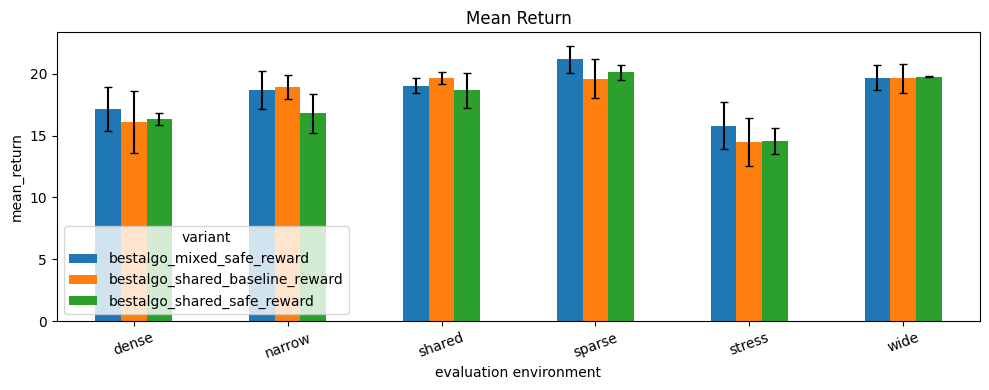

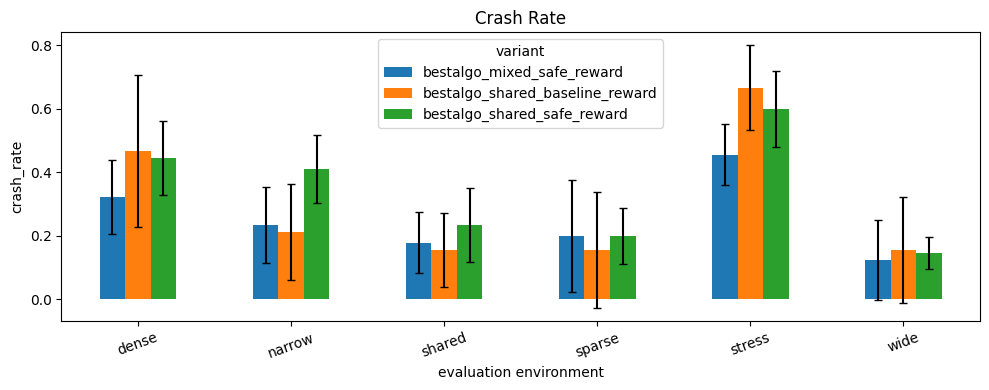

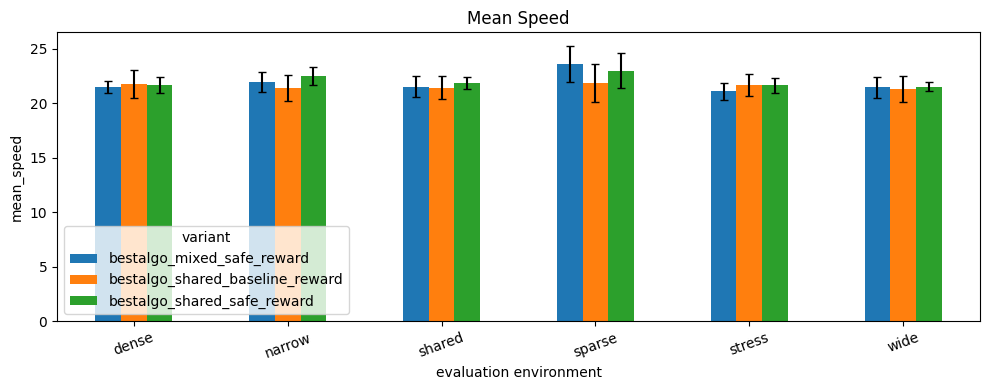

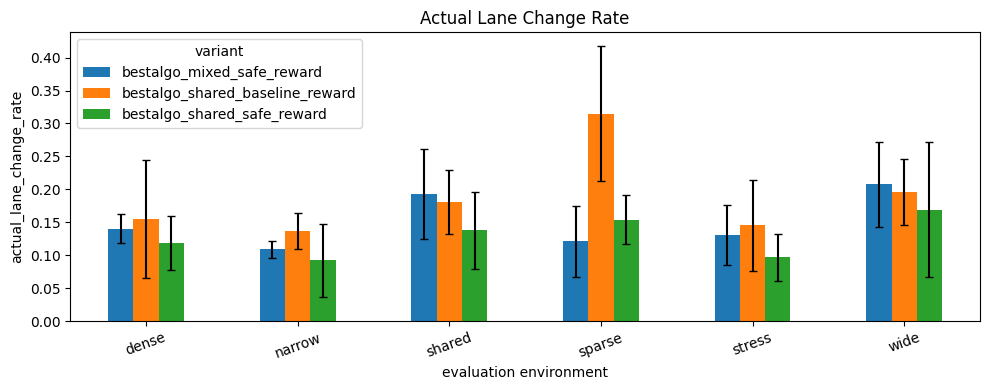

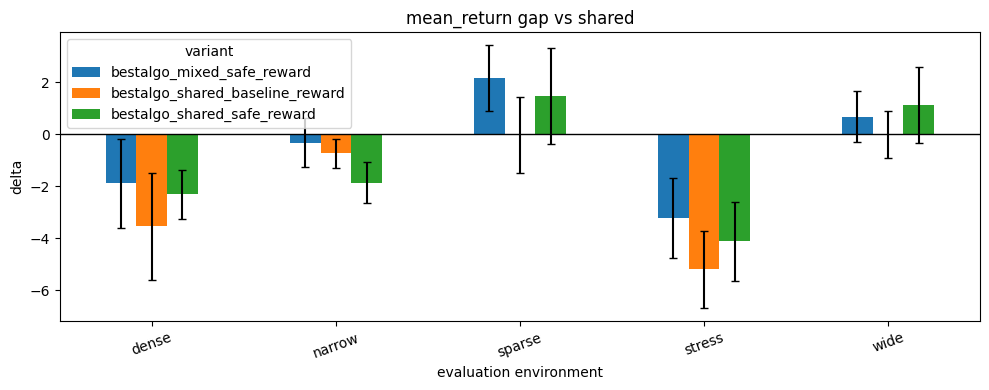

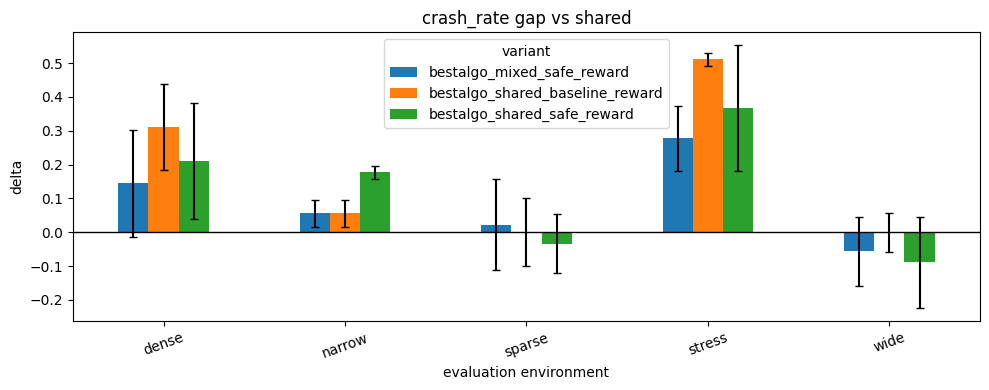

In [19]:
safety_results_df = run_evaluation_study(
    study_name="safety_study",
    variants=safety_variants,
    agents_by_run=safety_agents,
    eval_seeds=SAFETY_EVAL_SEEDS,
    eval_env_names=SAFETY_EVAL_ENVS,
)

display(safety_results_df.round(3))
display(make_extension_summary_table(safety_results_df))

plot_extension_metric(safety_results_df, "mean_return")
plot_extension_metric(safety_results_df, "crash_rate")
plot_extension_metric(safety_results_df, "mean_speed")
plot_extension_metric(safety_results_df, "actual_lane_change_rate")

plot_generalization_gap(safety_results_df, "mean_return", reference_env="shared")
plot_generalization_gap(safety_results_df, "crash_rate", reference_env="shared")


In [20]:
safety_ranking = rank_variants(safety_results_df)
display(safety_ranking.round(3))

BASELINE_SAFETY_VARIANT = "bestalgo_shared_baseline_reward"
BEST_OVERALL_SAFETY_VARIANT = safety_ranking.index[0]

non_baseline_candidates = [
    variant_name
    for variant_name in safety_ranking.index
    if variant_name != BASELINE_SAFETY_VARIANT
]
COMPARISON_SAFETY_VARIANT = (
    non_baseline_candidates[0]
    if len(non_baseline_candidates) > 0
    else BEST_OVERALL_SAFETY_VARIANT
)

print("Best overall safety variant:", BEST_OVERALL_SAFETY_VARIANT)
print("Variant used for qualitative comparison:", COMPARISON_SAFETY_VARIANT)


,crash_rate,mean_return,mean_length
variant,,,
bestalgo_mixed_safe_reward,0.252,18.595,26.041
bestalgo_shared_baseline_reward,0.302,18.066,25.617
bestalgo_shared_safe_reward,0.339,17.712,24.763


Best overall safety variant: bestalgo_mixed_safe_reward
Variant used for qualitative comparison: bestalgo_mixed_safe_reward


## Qualitative Analysis

We now compare the baseline backbone against the best non-baseline safety variant.

We look at:
- one rollout on the shared benchmark
- one rollout on the harder `stress` benchmark
- one failure case search on `stress`

This complements the numeric tables with concrete driving behavior.


In [21]:
baseline_agent = safety_agents[(BASELINE_SAFETY_VARIANT, 0)]
comparison_agent = safety_agents[(COMPARISON_SAFETY_VARIANT, 0)]

shared_env_config = build_eval_config("shared", observation_mode=OBSERVATION_BACKBONE)
stress_env_config = build_eval_config("stress", observation_mode=OBSERVATION_BACKBONE)


In [22]:
baseline_shared_rollout = record_custom_rollout(
    baseline_agent,
    seed=1234,
    gif_path=ARTIFACTS / "rollouts" / "baseline_shared.gif",
    env_config=shared_env_config,
)

comparison_shared_rollout = record_custom_rollout(
    comparison_agent,
    seed=1234,
    gif_path=ARTIFACTS / "rollouts" / "comparison_shared.gif",
    env_config=shared_env_config,
)

print_rollout_summary(baseline_shared_rollout, label=BASELINE_SAFETY_VARIANT)
print_rollout_summary(comparison_shared_rollout, label=COMPARISON_SAFETY_VARIANT)

show_side_by_side_gifs(
    baseline_shared_rollout["gif_path"],
    comparison_shared_rollout["gif_path"],
    left_title=BASELINE_SAFETY_VARIANT,
    right_title=COMPARISON_SAFETY_VARIANT,
)


bestalgo_shared_baseline_reward: seed=1234, return=20.57, crashed=False
bestalgo_mixed_safe_reward: seed=1234, return=20.45, crashed=False


In [23]:
baseline_stress_rollout = record_custom_rollout(
    baseline_agent,
    seed=2024,
    gif_path=ARTIFACTS / "rollouts" / "baseline_stress.gif",
    env_config=stress_env_config,
)

comparison_stress_rollout = record_custom_rollout(
    comparison_agent,
    seed=2024,
    gif_path=ARTIFACTS / "rollouts" / "comparison_stress.gif",
    env_config=stress_env_config,
)

print_rollout_summary(baseline_stress_rollout, label=f"{BASELINE_SAFETY_VARIANT} stress")
print_rollout_summary(comparison_stress_rollout, label=f"{COMPARISON_SAFETY_VARIANT} stress")

show_side_by_side_gifs(
    baseline_stress_rollout["gif_path"],
    comparison_stress_rollout["gif_path"],
    left_title=f"{BASELINE_SAFETY_VARIANT} stress",
    right_title=f"{COMPARISON_SAFETY_VARIANT} stress",
)


bestalgo_shared_baseline_reward stress: seed=2024, return=2.28, crashed=True
bestalgo_mixed_safe_reward stress: seed=2024, return=3.41, crashed=True


bestalgo_shared_baseline_reward failure case: seed=3000, return=8.51, crashed=True


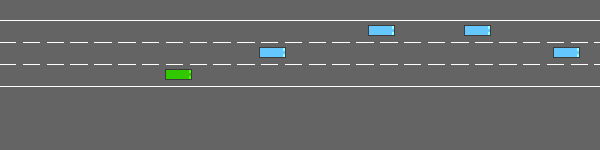

bestalgo_mixed_safe_reward failure case: seed=3000, return=6.14, crashed=True


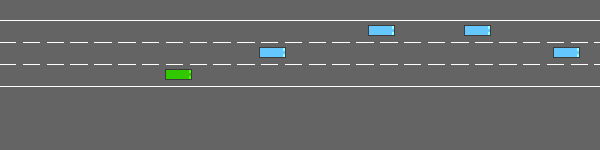

In [24]:
baseline_failure = find_custom_failure_case(
    baseline_agent,
    seeds=range(3000, 3100),
    env_config=stress_env_config,
)

comparison_failure = find_custom_failure_case(
    comparison_agent,
    seeds=range(3000, 3100),
    env_config=stress_env_config,
)

print_failure_case(baseline_failure, label=BASELINE_SAFETY_VARIANT)
print_failure_case(comparison_failure, label=COMPARISON_SAFETY_VARIANT)


## Final Discussion

At this point the notebook contains:
- an observation comparison
- a clean kinematics ablation for Double DQN and PER
- a principled safe-reward selection step
- a safety and generalization comparison built on the best backbone
- qualitative rollouts and failure cases

The final interpretation should focus on:
- whether `OccupancyGrid` justified its extra complexity
- whether Double DQN and PER improved the custom baseline
- whether safe reward shaping and mixed-traffic training reduced crashes
- whether safety gains held under shifted traffic settings such as `dense` and `stress`
- what tradeoff appeared between reward, speed, lane changes, and crash rate
